# SECOM EDA Decision Report

This notebook is the preprocessing decision record for the raw SECOM wafer data. Each section makes the data-quality tradeoff visible before moving to the next decision.

In [1]:
import sys
from pathlib import Path
from textwrap import wrap

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import patches

from yield_risk.data import load_secom
from yield_risk.validation import validate_secom

%matplotlib inline

plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.titlesize": 11,
        "axes.labelsize": 9,
        "font.size": 9,
    }
)

NON_SENSOR = {"label", "timestamp"}
BLUE = "#2F80ED"
RED = "#D64545"
ORANGE = "#F2994A"
GREEN = "#219653"
PURPLE = "#7B61FF"
GRAY = "#6B7280"
LIGHT = "#F5F7FA"
DARK = "#1F2937"

MISSING_THRESH = 0.10
MAJORITY_MISSING_BOUNDARY = 0.50
ABS_VAR_REFERENCE = 0.01
CV_THRESH = 0.01
CORR_THRESH = 0.95


def sensor_columns(frame: pd.DataFrame) -> list[str]:
    """Return sensor columns from a SECOM-like frame."""
    return [col for col in frame.columns if col not in NON_SENSOR]


def metric_card(
    ax: plt.Axes,
    label: str,
    value: str,
    note: str,
    color: str = BLUE,
) -> None:
    """Draw a compact visual metric card."""
    ax.set_axis_off()
    card = patches.FancyBboxPatch(
        (0.02, 0.08),
        0.96,
        0.84,
        boxstyle="round,pad=0.018,rounding_size=0.02",
        transform=ax.transAxes,
        linewidth=1.2,
        edgecolor=color,
        facecolor=LIGHT,
    )
    ax.add_patch(card)
    ax.text(0.07, 0.72, label.upper(), transform=ax.transAxes, color=GRAY, weight="bold", fontsize=8)
    ax.text(0.07, 0.43, value, transform=ax.transAxes, color=color, weight="bold", fontsize=18)
    y = 0.23
    for line in wrap(note, width=34)[:3]:
        ax.text(0.07, y, line, transform=ax.transAxes, color=DARK, fontsize=8)
        y -= 0.09


def decision_card(
    ax: plt.Axes,
    title: str,
    lines: list[str],
    color: str = GREEN,
    wrap_width: int = 48,
) -> None:
    """Draw a short decision callout with wrapped bullets."""
    ax.set_axis_off()
    card = patches.FancyBboxPatch(
        (0.02, 0.04),
        0.96,
        0.92,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        transform=ax.transAxes,
        linewidth=1.4,
        edgecolor=color,
        facecolor="#FFFFFF",
    )
    ax.add_patch(card)
    ax.text(0.07, 0.84, title, transform=ax.transAxes, color=color, weight="bold", fontsize=11)
    y = 0.66
    for line in lines:
        wrapped = wrap(line, width=wrap_width) or [line]
        for idx, piece in enumerate(wrapped[:2]):
            prefix = "- " if idx == 0 else "  "
            ax.text(0.09, y, f"{prefix}{piece}", transform=ax.transAxes, color=DARK, fontsize=8.5)
            y -= 0.10
        y -= 0.05


def report_table(
    ax: plt.Axes,
    frame: pd.DataFrame,
    title: str,
    max_rows: int = 12,
    font_size: float = 7.0,
    scale_y: float = 1.25,
) -> None:
    """Render a compact table with short, pre-wrapped values."""
    ax.set_axis_off()
    ax.set_title(title, loc="left", pad=8)
    shown = frame.head(max_rows).copy()
    for col in shown.columns:
        if pd.api.types.is_float_dtype(shown[col]):
            shown[col] = shown[col].map(lambda value: "" if pd.isna(value) else f"{value:.3g}")
        elif pd.api.types.is_integer_dtype(shown[col]):
            shown[col] = shown[col].map(lambda value: f"{value:,}")
    table = ax.table(
        cellText=shown.values,
        colLabels=shown.columns,
        loc="center",
        cellLoc="left",
        colLoc="left",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1, scale_y)
    for (row, _col), cell in table.get_celld().items():
        cell.set_edgecolor("#D7DEE8")
        if row == 0:
            cell.set_facecolor("#E8F1FD")
            cell.set_text_props(weight="bold", color=DARK)
        else:
            cell.set_facecolor("#FFFFFF" if row % 2 else "#F8FAFC")

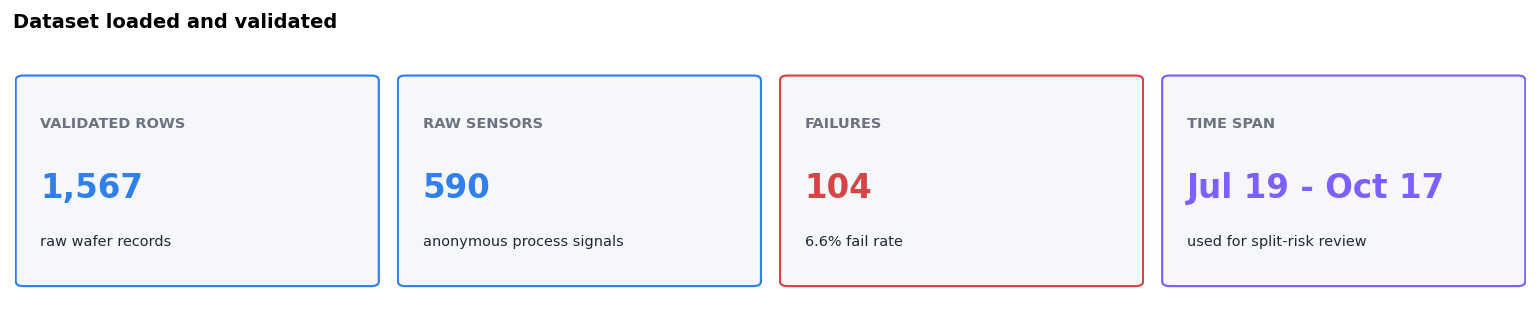

In [2]:
raw_dir = project_root / "data" / "raw"

df = load_secom(raw_dir)
validate_secom(df)

sensor_cols = sensor_columns(df)
timestamp_parsed = pd.to_datetime(df["timestamp"], errors="coerce")
if timestamp_parsed.isna().all():
    timestamp_parsed = pd.to_datetime(
        df["timestamp"].astype(str).str.strip('"'),
        format="%d/%m/%Y %H:%M:%S",
        errors="coerce",
    )

fig, axes = plt.subplots(1, 4, figsize=(12, 2.4))
metric_card(axes[0], "validated rows", f"{len(df):,}", "raw wafer records")
metric_card(axes[1], "raw sensors", f"{len(sensor_cols):,}", "anonymous process signals")
metric_card(axes[2], "failures", f"{int(df['label'].sum()):,}", f"{df['label'].mean():.1%} fail rate", RED)
metric_card(
    axes[3],
    "time span",
    f"{timestamp_parsed.min():%b %d} - {timestamp_parsed.max():%b %d}",
    "used for split-risk review",
    PURPLE,
)
fig.suptitle("Dataset loaded and validated", x=0.01, ha="left", weight="bold")
plt.tight_layout()

## 1. Class Balance Sets the Modeling Objective

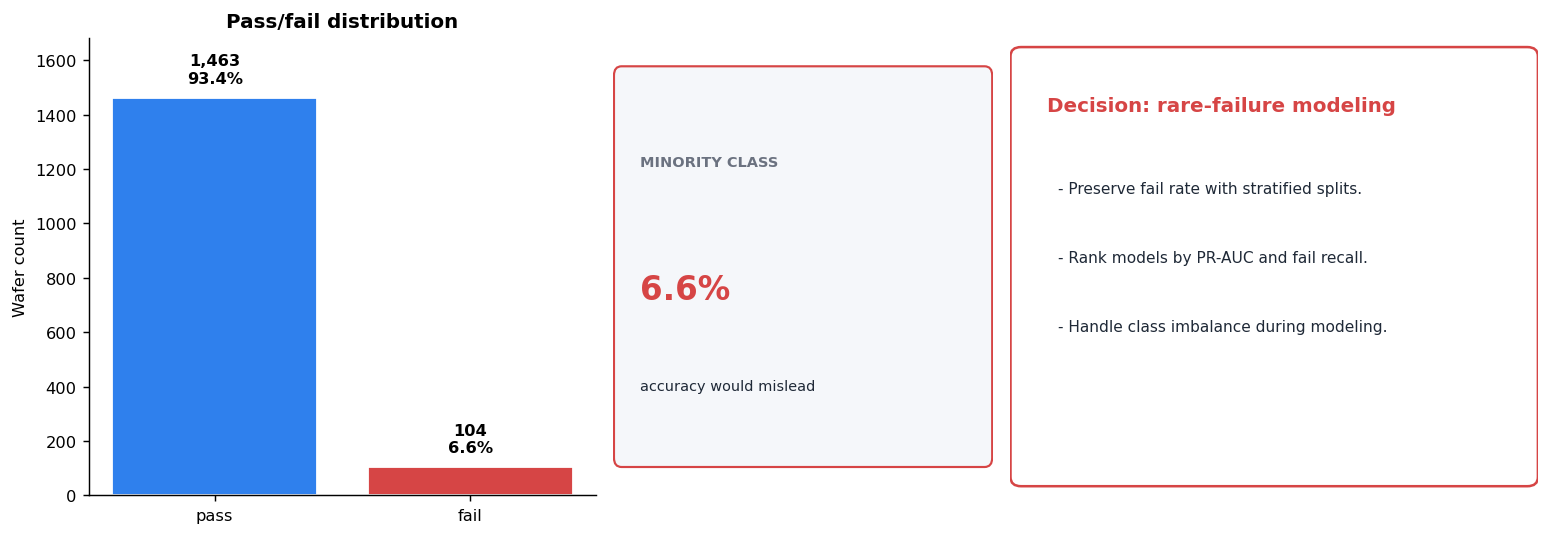

In [3]:
counts = df["label"].map({0: "pass", 1: "fail"}).value_counts().reindex(["pass", "fail"])
fail_rate = counts["fail"] / counts.sum()

fig = plt.figure(figsize=(12, 4.2))
grid = fig.add_gridspec(1, 3, width_ratios=[1.2, 0.9, 1.25])
ax_bar = fig.add_subplot(grid[0, 0])
ax_metric = fig.add_subplot(grid[0, 1])
ax_decision = fig.add_subplot(grid[0, 2])

bars = ax_bar.bar(counts.index, counts.values, color=[BLUE, RED], edgecolor="white")
ax_bar.set_title("Pass/fail distribution")
ax_bar.set_ylabel("Wafer count")
ax_bar.set_ylim(0, counts.max() * 1.15)
for bar, value in zip(bars, counts.values, strict=True):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        value + counts.max() * 0.03,
        f"{value:,}\n{value / counts.sum():.1%}",
        ha="center",
        va="bottom",
        weight="bold",
    )

metric_card(ax_metric, "minority class", f"{fail_rate:.1%}", "accuracy would mislead", RED)
decision_card(
    ax_decision,
    "Decision: rare-failure modeling",
    [
        "Preserve fail rate with stratified splits.",
        "Rank models by PR-AUC and fail recall.",
        "Handle class imbalance during modeling.",
    ],
    RED,
)
plt.tight_layout()

## 2. Missingness Filter Uses a 10% Cutoff

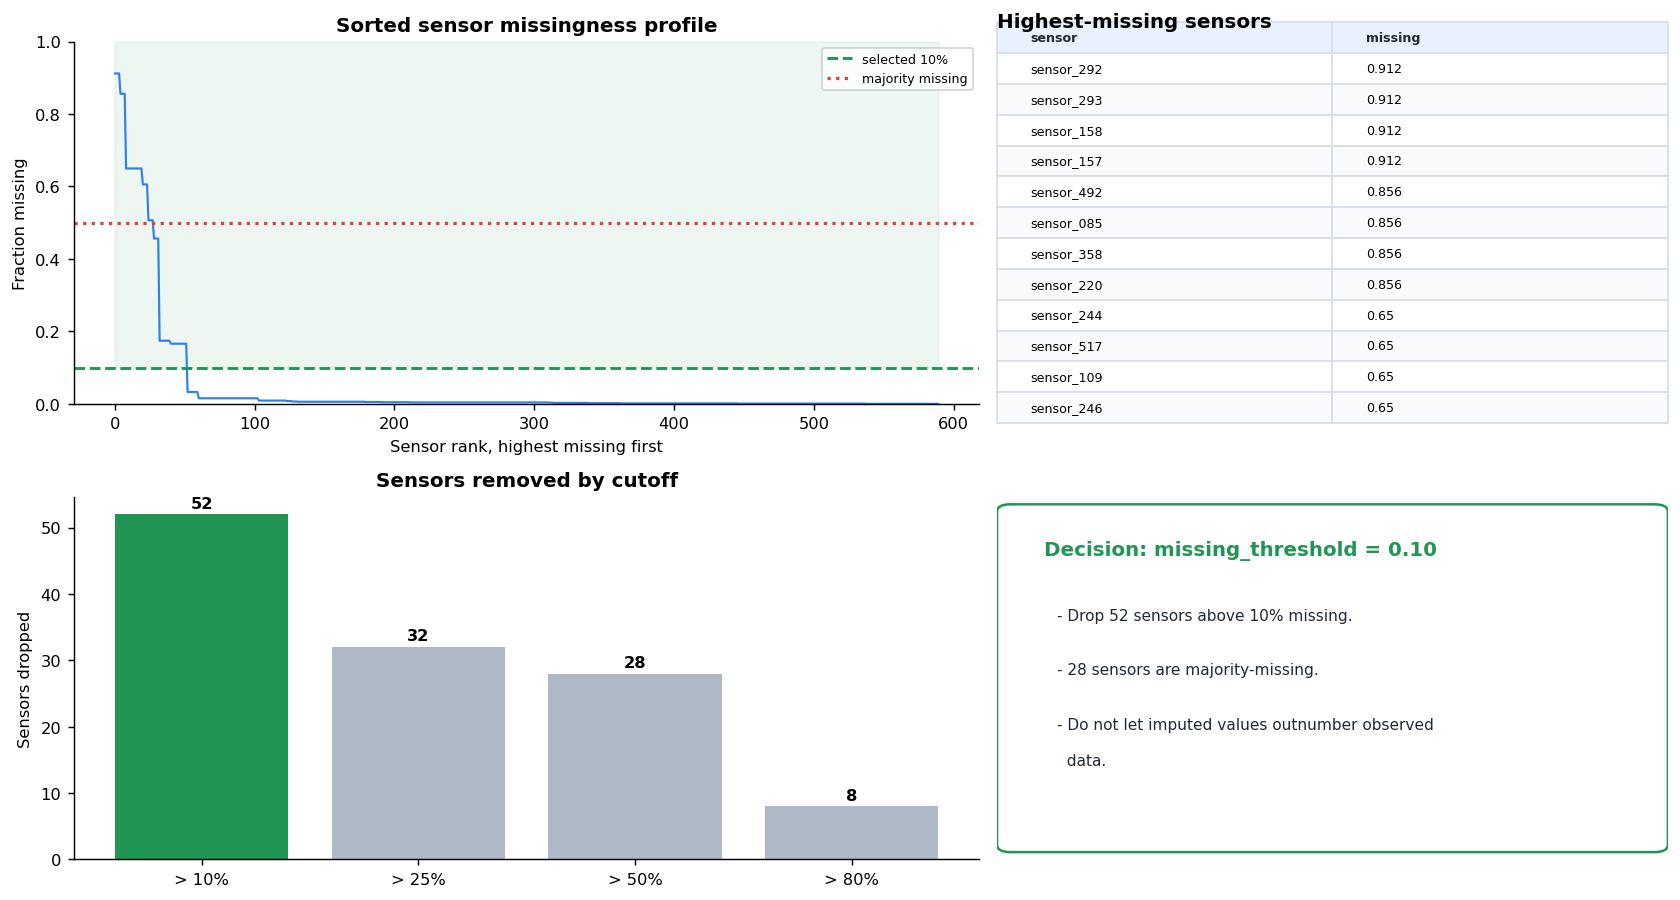

In [4]:
missing_rate = df[sensor_cols].isna().mean().sort_values(ascending=False)
missing_thresholds = [0.10, 0.25, 0.50, 0.80]
missing_counts = pd.DataFrame(
    {
        "cutoff": [f"> {threshold:.0%}" for threshold in missing_thresholds],
        "drop": [int((missing_rate > threshold).sum()) for threshold in missing_thresholds],
    }
)
missing_drop = missing_rate[missing_rate > MISSING_THRESH]
missing_keep = missing_rate[missing_rate <= MISSING_THRESH]
majority_missing = int((missing_rate > MAJORITY_MISSING_BOUNDARY).sum())

fig = plt.figure(figsize=(13, 7))
grid = fig.add_gridspec(2, 2, width_ratios=[1.35, 1.0], height_ratios=[1.0, 1.0])
ax_profile = fig.add_subplot(grid[0, 0])
ax_counts = fig.add_subplot(grid[1, 0])
ax_table = fig.add_subplot(grid[0, 1])
ax_decision = fig.add_subplot(grid[1, 1])

ax_profile.plot(missing_rate.values, color=BLUE, linewidth=1.2)
ax_profile.axhline(MISSING_THRESH, color=GREEN, linestyle="--", linewidth=1.6, label="selected 10%")
ax_profile.axhline(
    MAJORITY_MISSING_BOUNDARY,
    color=RED,
    linestyle=":",
    linewidth=1.8,
    label="majority missing",
)
ax_profile.fill_between(np.arange(len(missing_rate)), MISSING_THRESH, 1, color=GREEN, alpha=0.08)
ax_profile.set_title("Sorted sensor missingness profile")
ax_profile.set_xlabel("Sensor rank, highest missing first")
ax_profile.set_ylabel("Fraction missing")
ax_profile.set_ylim(0, 1.0)
ax_profile.legend(loc="upper right", fontsize=7)

bar_colors = [GREEN if label == "> 10%" else "#AEB8C7" for label in missing_counts["cutoff"]]
bars = ax_counts.bar(missing_counts["cutoff"], missing_counts["drop"], color=bar_colors)
ax_counts.set_title("Sensors removed by cutoff")
ax_counts.set_ylabel("Sensors dropped")
for bar, value in zip(bars, missing_counts["drop"], strict=True):
    ax_counts.text(bar.get_x() + bar.get_width() / 2, value + 1, str(value), ha="center", weight="bold")

top_missing = missing_rate.head(12).rename("missing").reset_index().rename(columns={"index": "sensor"})
report_table(ax_table, top_missing, "Highest-missing sensors", max_rows=12)
decision_card(
    ax_decision,
    "Decision: missing_threshold = 0.10",
    [
        f"Drop {len(missing_drop)} sensors above 10% missing.",
        f"{majority_missing} sensors are majority-missing.",
        "Do not let imputed values outnumber observed data.",
    ],
    GREEN,
)
plt.tight_layout()

## 3. Variance Is Scale-Dependent

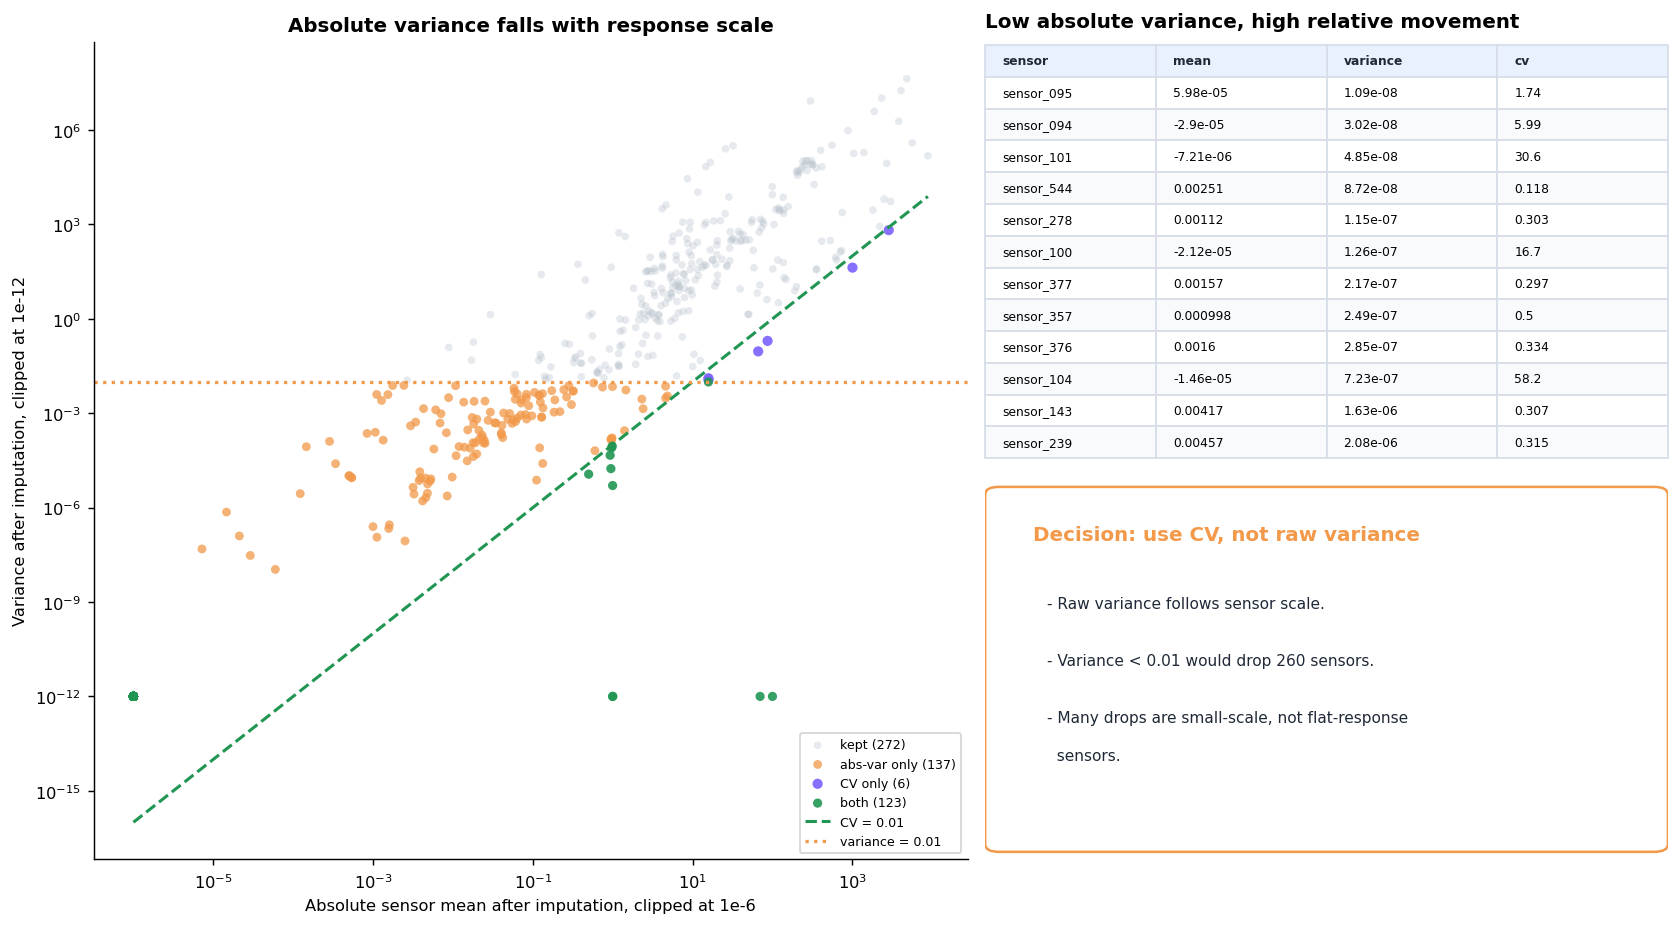

In [5]:
sensor_cols_missing_ok = missing_keep.index.tolist()
df_imputed = df[sensor_cols_missing_ok].fillna(df[sensor_cols_missing_ok].median())

means = df_imputed.mean()
abs_means = means.abs()
stds = df_imputed.std()
variances = df_imputed.var()
cv_raw = (stds / abs_means.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
cv_for_filter = cv_raw.copy()
cv_for_filter[(abs_means == 0) & (stds == 0)] = 0.0
cv_for_filter[(abs_means == 0) & (stds > 0)] = np.inf

variance_report = pd.DataFrame(
    {
        "mean": means,
        "abs_mean": abs_means,
        "std": stds,
        "variance": variances,
        "cv": cv_for_filter,
    }
)

abs_var_drop = variance_report[variance_report["variance"] < ABS_VAR_REFERENCE].sort_values("variance")
cv_drop = variance_report[variance_report["cv"] < CV_THRESH].sort_values("cv")

abs_var_drop_set = set(abs_var_drop.index)
cv_drop_set = set(cv_drop.index)
all_after_missing = set(variance_report.index)
both_drop = abs_var_drop_set & cv_drop_set
abs_only_drop = abs_var_drop_set - cv_drop_set
cv_only_drop = cv_drop_set - abs_var_drop_set
neither_drop = all_after_missing - abs_var_drop_set - cv_drop_set

fig = plt.figure(figsize=(13, 7.2))
grid = fig.add_gridspec(2, 2, width_ratios=[1.28, 1.0], height_ratios=[1.05, 0.95])
ax_scatter = fig.add_subplot(grid[:, 0])
ax_table = fig.add_subplot(grid[0, 1])
ax_decision = fig.add_subplot(grid[1, 1])

plot_df = variance_report.copy()
plot_df["plot_mean"] = plot_df["abs_mean"].clip(lower=1e-6)
plot_df["plot_variance"] = plot_df["variance"].clip(lower=1e-12)
plot_df["group"] = "kept"
plot_df.loc[list(abs_only_drop), "group"] = "abs-var only"
plot_df.loc[list(cv_only_drop), "group"] = "CV only"
plot_df.loc[list(both_drop), "group"] = "both"

styles = {
    "kept": ("#B8C2CC", 0.35, 18),
    "abs-var only": (ORANGE, 0.75, 24),
    "CV only": (PURPLE, 0.90, 32),
    "both": (GREEN, 0.90, 26),
}
for group, (color, alpha, size) in styles.items():
    subset = plot_df[plot_df["group"] == group]
    ax_scatter.scatter(
        subset["plot_mean"],
        subset["plot_variance"],
        s=size,
        color=color,
        alpha=alpha,
        edgecolor="none",
        label=f"{group} ({len(subset)})",
    )

x_line = np.logspace(-6, np.log10(plot_df["plot_mean"].max()), 300)
ax_scatter.plot(x_line, (CV_THRESH * x_line) ** 2, color=GREEN, linestyle="--", linewidth=1.7, label="CV = 0.01")
ax_scatter.axhline(ABS_VAR_REFERENCE, color=ORANGE, linestyle=":", linewidth=1.8, label="variance = 0.01")
ax_scatter.set_xscale("log")
ax_scatter.set_yscale("log")
ax_scatter.set_title("Absolute variance falls with response scale")
ax_scatter.set_xlabel("Absolute sensor mean after imputation, clipped at 1e-6")
ax_scatter.set_ylabel("Variance after imputation, clipped at 1e-12")
ax_scatter.legend(fontsize=7, loc="lower right")

abs_only_examples = (
    variance_report.loc[sorted(abs_only_drop)]
    .query("variance > 0")
    .sort_values("variance")
    .reset_index(names="sensor")[["sensor", "mean", "variance", "cv"]]
    .head(12)
)
report_table(ax_table, abs_only_examples, "Low absolute variance, high relative movement", max_rows=12, font_size=6.8, scale_y=1.2)
decision_card(
    ax_decision,
    "Decision: use CV, not raw variance",
    [
        "Raw variance follows sensor scale.",
        f"Variance < 0.01 would drop {len(abs_var_drop)} sensors.",
        "Many drops are small-scale, not flat-response sensors.",
    ],
    ORANGE,
)
plt.tight_layout()

## 4. CV 0.01 Is the Low-Variation Filter

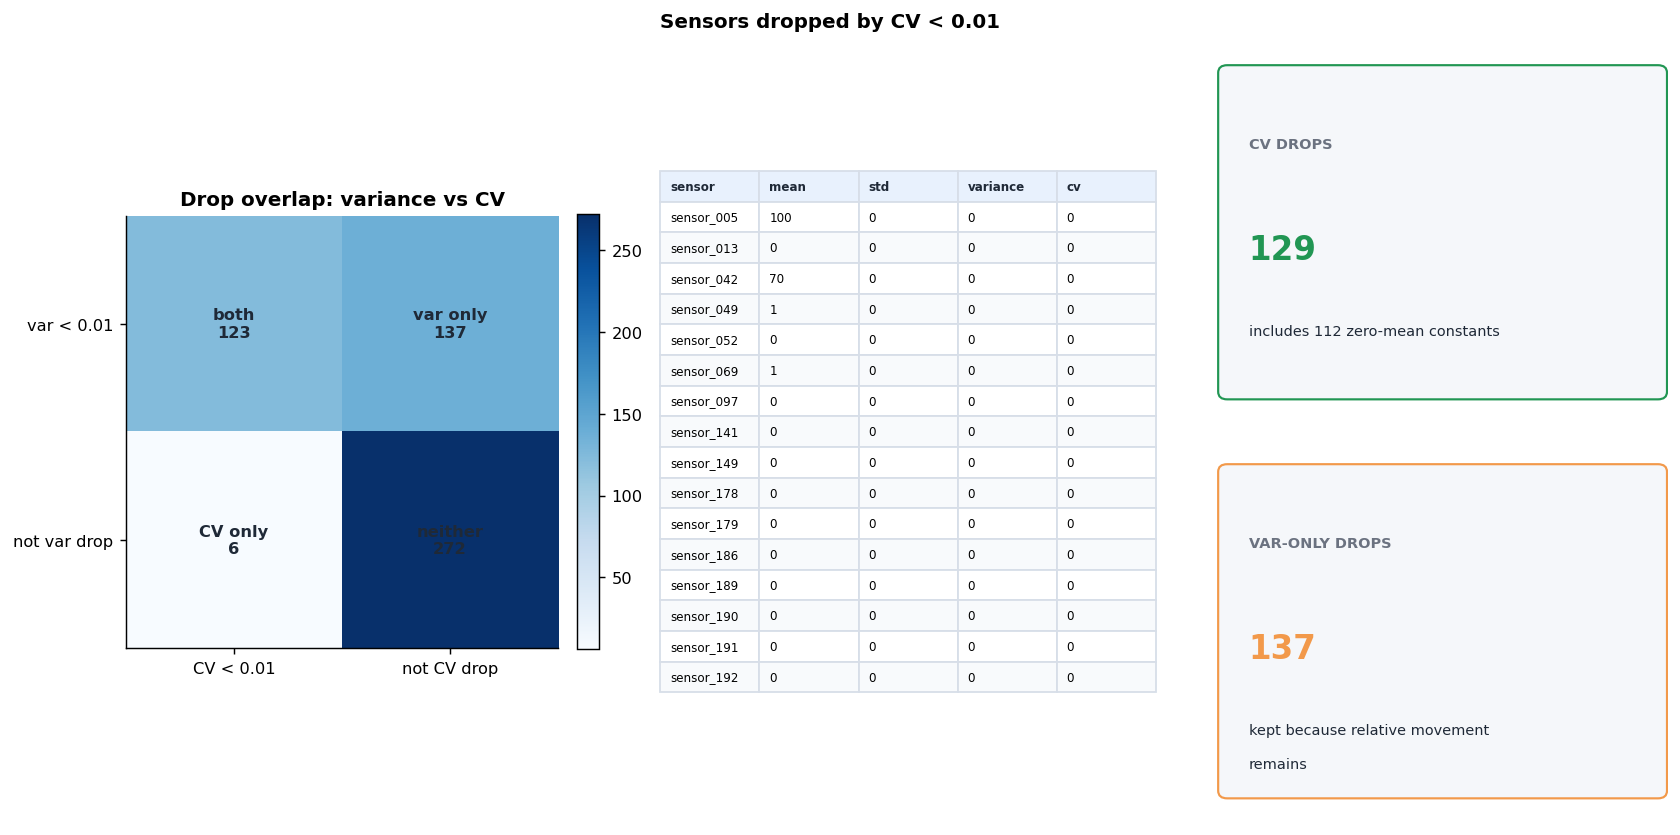

In [6]:
matrix = np.array(
    [
        [len(both_drop), len(abs_only_drop)],
        [len(cv_only_drop), len(neither_drop)],
    ]
)
zero_constant_cv = int(((variance_report["abs_mean"] == 0) & (variance_report["std"] == 0) & (variance_report["cv"] < CV_THRESH)).sum())

fig = plt.figure(figsize=(13, 6.5))
grid = fig.add_gridspec(2, 3, width_ratios=[1.05, 1.1, 1.0], height_ratios=[1.0, 1.0])
ax_matrix = fig.add_subplot(grid[:, 0])
ax_table = fig.add_subplot(grid[:, 1])
ax_metric_1 = fig.add_subplot(grid[0, 2])
ax_metric_2 = fig.add_subplot(grid[1, 2])

image = ax_matrix.imshow(matrix, cmap="Blues")
ax_matrix.set_title("Drop overlap: variance vs CV")
ax_matrix.set_xticks([0, 1], labels=["CV < 0.01", "not CV drop"])
ax_matrix.set_yticks([0, 1], labels=["var < 0.01", "not var drop"])
labels = np.array([["both", "var only"], ["CV only", "neither"]])
for row in range(2):
    for col in range(2):
        ax_matrix.text(col, row, f"{labels[row, col]}\n{matrix[row, col]:,}", ha="center", va="center", weight="bold", color=DARK)
fig.colorbar(image, ax=ax_matrix, fraction=0.046, pad=0.04)

cv_table = (
    cv_drop.reset_index(names="sensor")[["sensor", "mean", "std", "variance", "cv"]]
    .sort_values(["cv", "sensor"])
    .head(16)
)
report_table(ax_table, cv_table, "Sensors dropped by CV < 0.01", max_rows=16, font_size=6.6, scale_y=1.18)
metric_card(ax_metric_1, "CV drops", f"{len(cv_drop):,}", f"includes {zero_constant_cv} zero-mean constants", GREEN)
metric_card(ax_metric_2, "var-only drops", f"{len(abs_only_drop):,}", "kept because relative movement remains", ORANGE)
plt.tight_layout()

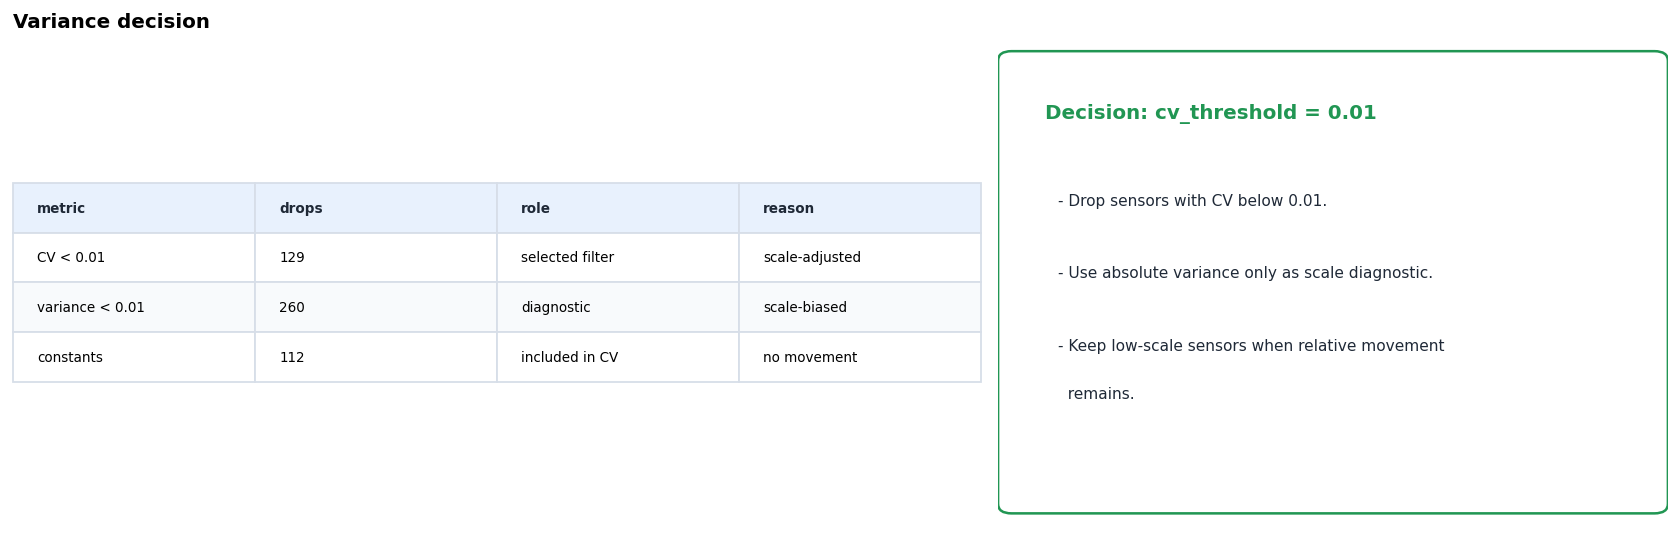

In [7]:
variance_choice = pd.DataFrame(
    [
        {"metric": "CV < 0.01", "drops": len(cv_drop), "role": "selected filter", "reason": "scale-adjusted"},
        {"metric": "variance < 0.01", "drops": len(abs_var_drop), "role": "diagnostic", "reason": "scale-biased"},
        {"metric": "constants", "drops": zero_constant_cv, "role": "included in CV", "reason": "no movement"},
    ]
)

fig = plt.figure(figsize=(13, 4.2))
grid = fig.add_gridspec(1, 2, width_ratios=[1.3, 0.9])
ax_table = fig.add_subplot(grid[0, 0])
ax_decision = fig.add_subplot(grid[0, 1])

report_table(ax_table, variance_choice, "Variance decision", max_rows=3, font_size=7.5, scale_y=2.0)
decision_card(
    ax_decision,
    "Decision: cv_threshold = 0.01",
    [
        "Drop sensors with CV below 0.01.",
        "Use absolute variance only as scale diagnostic.",
        "Keep low-scale sensors when relative movement remains.",
    ],
    GREEN,
)
plt.tight_layout()

## 5. Correlation Filter Compresses Redundant Sensors

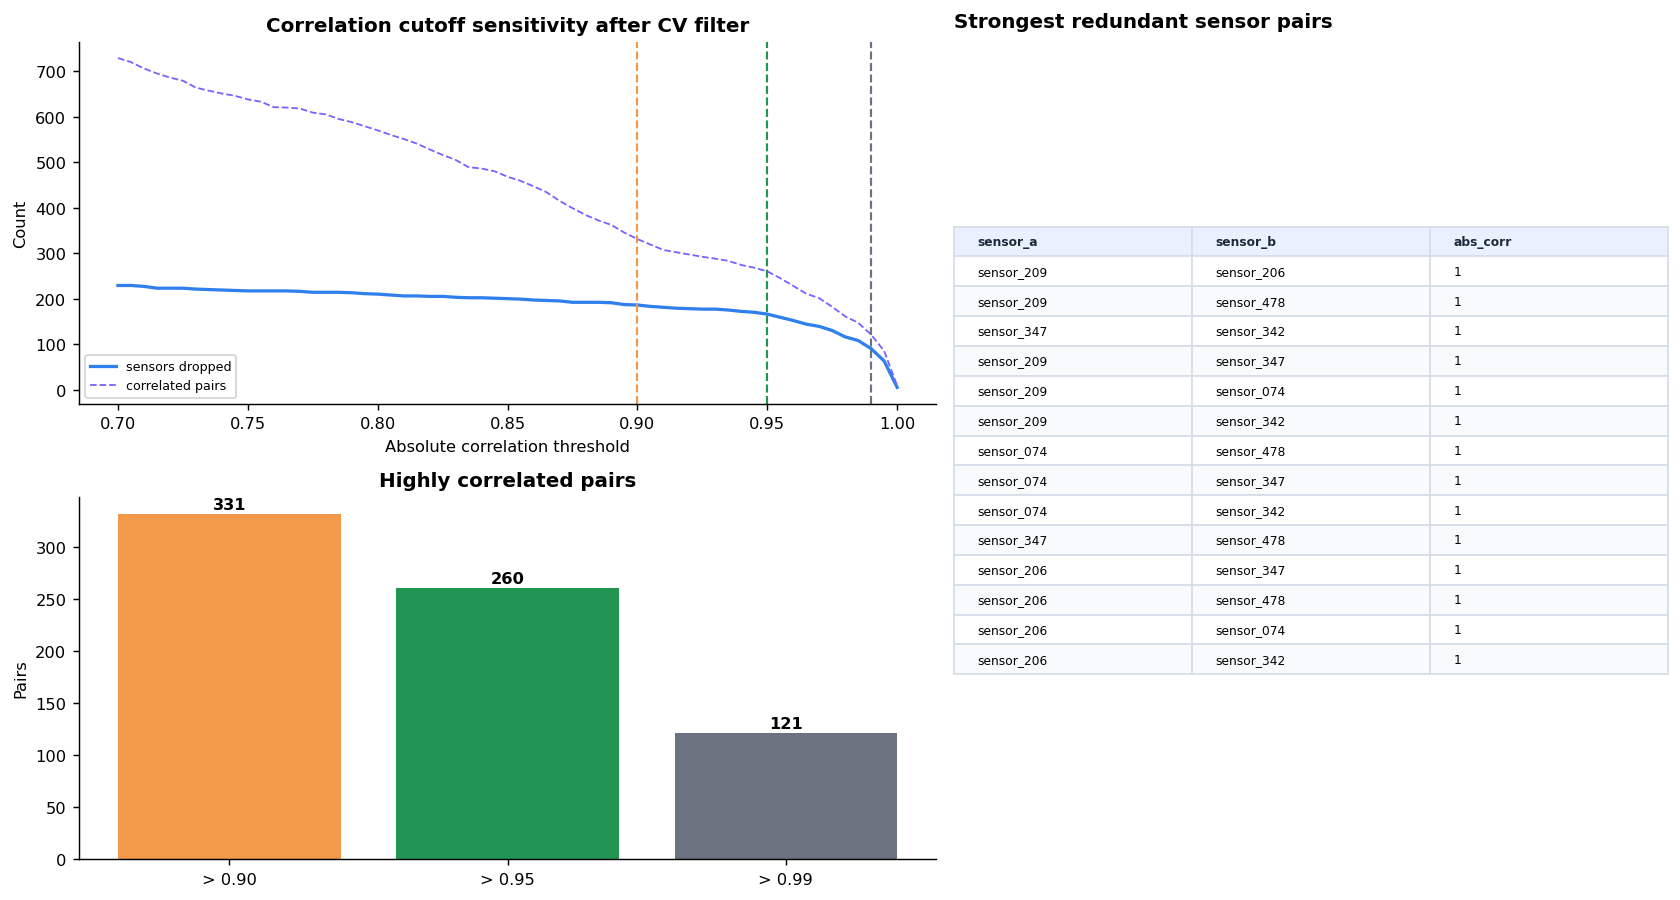

In [8]:
cv_keep = [sensor for sensor in sensor_cols_missing_ok if sensor not in cv_drop_set]
df_after_cv = df_imputed[cv_keep]

corr = df_after_cv.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))

corr_thresholds = np.linspace(0.70, 1.00, 61)
corr_drop_counts = [len([col for col in upper.columns if bool((upper[col] > threshold).any())]) for threshold in corr_thresholds]
corr_pairs_counts = [int((upper > threshold).sum().sum()) for threshold in corr_thresholds]
corr_drop = [col for col in upper.columns if bool((upper[col] > CORR_THRESH).any())]
corr_keep = [sensor for sensor in cv_keep if sensor not in corr_drop]

top_corr_pairs = (
    upper.stack()
    .rename("abs_corr")
    .reset_index()
    .rename(columns={"level_0": "sensor_a", "level_1": "sensor_b"})
    .sort_values("abs_corr", ascending=False)
    .head(14)
)

fig = plt.figure(figsize=(13, 7))
grid = fig.add_gridspec(2, 2, width_ratios=[1.2, 1.0], height_ratios=[1.0, 1.0])
ax_line = fig.add_subplot(grid[0, 0])
ax_pairs = fig.add_subplot(grid[1, 0])
ax_table = fig.add_subplot(grid[:, 1])

ax_line.plot(corr_thresholds, corr_drop_counts, color=BLUE, linewidth=1.8, label="sensors dropped")
ax_line.plot(corr_thresholds, corr_pairs_counts, color=PURPLE, linewidth=1.0, linestyle="--", label="correlated pairs")
for threshold, color in [(0.90, ORANGE), (CORR_THRESH, GREEN), (0.99, GRAY)]:
    ax_line.axvline(threshold, color=color, linestyle="--", linewidth=1.2)
ax_line.set_title("Correlation cutoff sensitivity after CV filter")
ax_line.set_xlabel("Absolute correlation threshold")
ax_line.set_ylabel("Count")
ax_line.legend(fontsize=7)

pair_bars = pd.Series(
    {
        "> 0.90": int((upper > 0.90).sum().sum()),
        "> 0.95": int((upper > 0.95).sum().sum()),
        "> 0.99": int((upper > 0.99).sum().sum()),
    }
)
bars = ax_pairs.bar(pair_bars.index, pair_bars.values, color=[ORANGE, GREEN, GRAY])
ax_pairs.set_title("Highly correlated pairs")
ax_pairs.set_ylabel("Pairs")
for bar, value in zip(bars, pair_bars.values, strict=True):
    ax_pairs.text(bar.get_x() + bar.get_width() / 2, value + 5, f"{value:,}", ha="center", weight="bold")

report_table(ax_table, top_corr_pairs, "Strongest redundant sensor pairs", max_rows=14, font_size=6.8, scale_y=1.18)
plt.tight_layout()

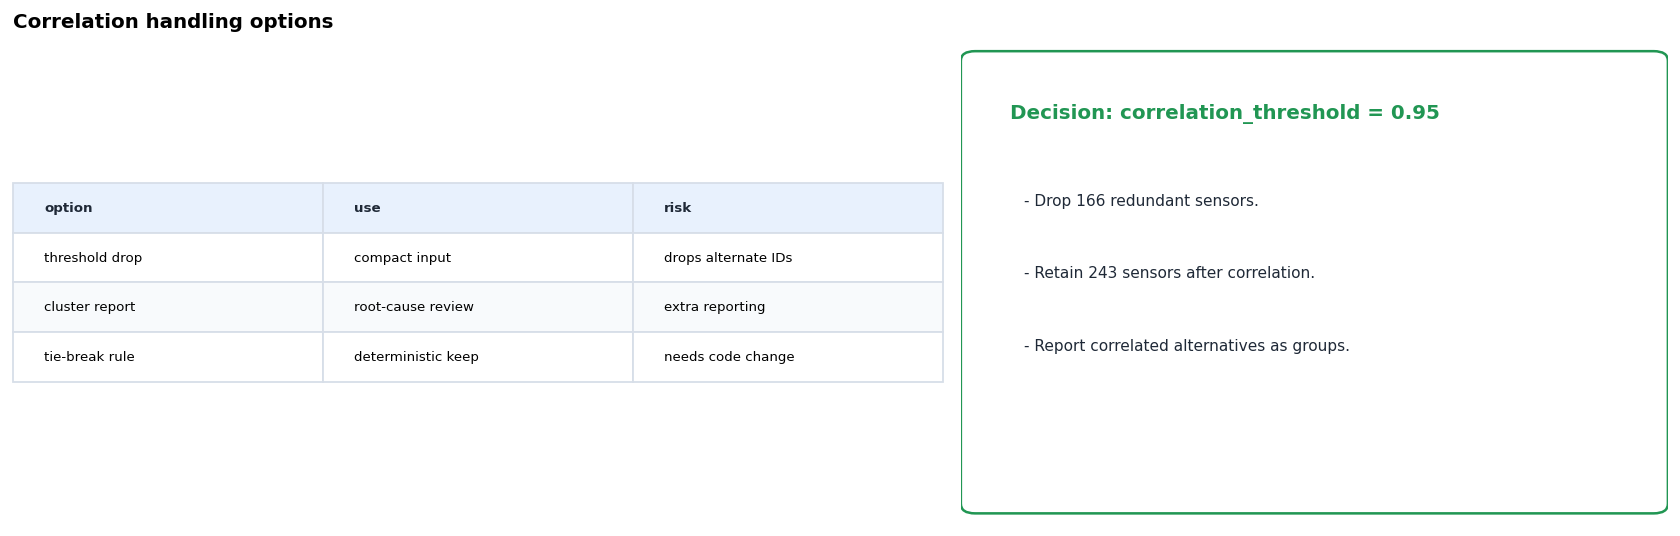

In [9]:
correlation_options = pd.DataFrame(
    [
        {"option": "threshold drop", "use": "compact input", "risk": "drops alternate IDs"},
        {"option": "cluster report", "use": "root-cause review", "risk": "extra reporting"},
        {"option": "tie-break rule", "use": "deterministic keep", "risk": "needs code change"},
    ]
)

fig = plt.figure(figsize=(13, 4.2))
grid = fig.add_gridspec(1, 2, width_ratios=[1.25, 0.95])
ax_table = fig.add_subplot(grid[0, 0])
ax_decision = fig.add_subplot(grid[0, 1])

report_table(ax_table, correlation_options, "Correlation handling options", max_rows=3, font_size=7.4, scale_y=2.0)
decision_card(
    ax_decision,
    f"Decision: correlation_threshold = {CORR_THRESH:.2f}",
    [
        f"Drop {len(corr_drop)} redundant sensors.",
        f"Retain {len(corr_keep)} sensors after correlation.",
        "Report correlated alternatives as groups.",
    ],
    GREEN,
)
plt.tight_layout()

## 6. Feature Count Through the Decisions

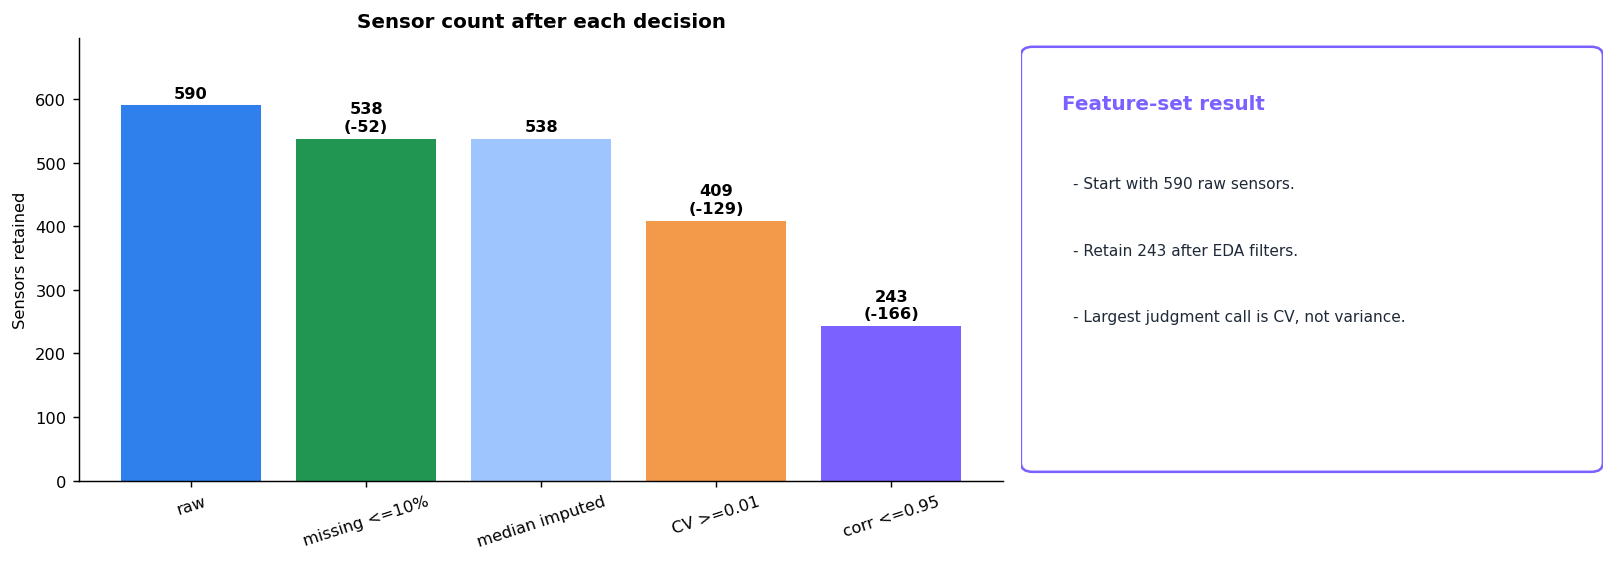

In [10]:
stage_counts = pd.DataFrame(
    [
        {"stage": "raw", "sensors": len(sensor_cols), "dropped": 0},
        {"stage": "missing <=10%", "sensors": len(sensor_cols_missing_ok), "dropped": len(sensor_cols) - len(sensor_cols_missing_ok)},
        {"stage": "median imputed", "sensors": len(sensor_cols_missing_ok), "dropped": 0},
        {"stage": "CV >=0.01", "sensors": len(cv_keep), "dropped": len(cv_drop)},
        {"stage": "corr <=0.95", "sensors": len(corr_keep), "dropped": len(corr_drop)},
    ]
)

fig = plt.figure(figsize=(12.5, 4.4))
grid = fig.add_gridspec(1, 2, width_ratios=[1.35, 0.85])
ax_bar = fig.add_subplot(grid[0, 0])
ax_decision = fig.add_subplot(grid[0, 1])

bars = ax_bar.bar(stage_counts["stage"], stage_counts["sensors"], color=[BLUE, GREEN, "#9EC5FE", ORANGE, PURPLE])
ax_bar.set_title("Sensor count after each decision")
ax_bar.set_ylabel("Sensors retained")
ax_bar.tick_params(axis="x", rotation=18)
for bar, sensors, dropped in zip(bars, stage_counts["sensors"], stage_counts["dropped"], strict=True):
    label = f"{sensors:,}"
    if dropped:
        label += f"\n(-{dropped:,})"
    ax_bar.text(bar.get_x() + bar.get_width() / 2, sensors + 12, label, ha="center", weight="bold")
ax_bar.set_ylim(0, stage_counts["sensors"].max() * 1.18)

decision_card(
    ax_decision,
    "Feature-set result",
    [
        f"Start with {len(sensor_cols)} raw sensors.",
        f"Retain {len(corr_keep)} after EDA filters.",
        "Largest judgment call is CV, not variance.",
    ],
    PURPLE,
)
plt.tight_layout()

## 7. Temporal Split Risk

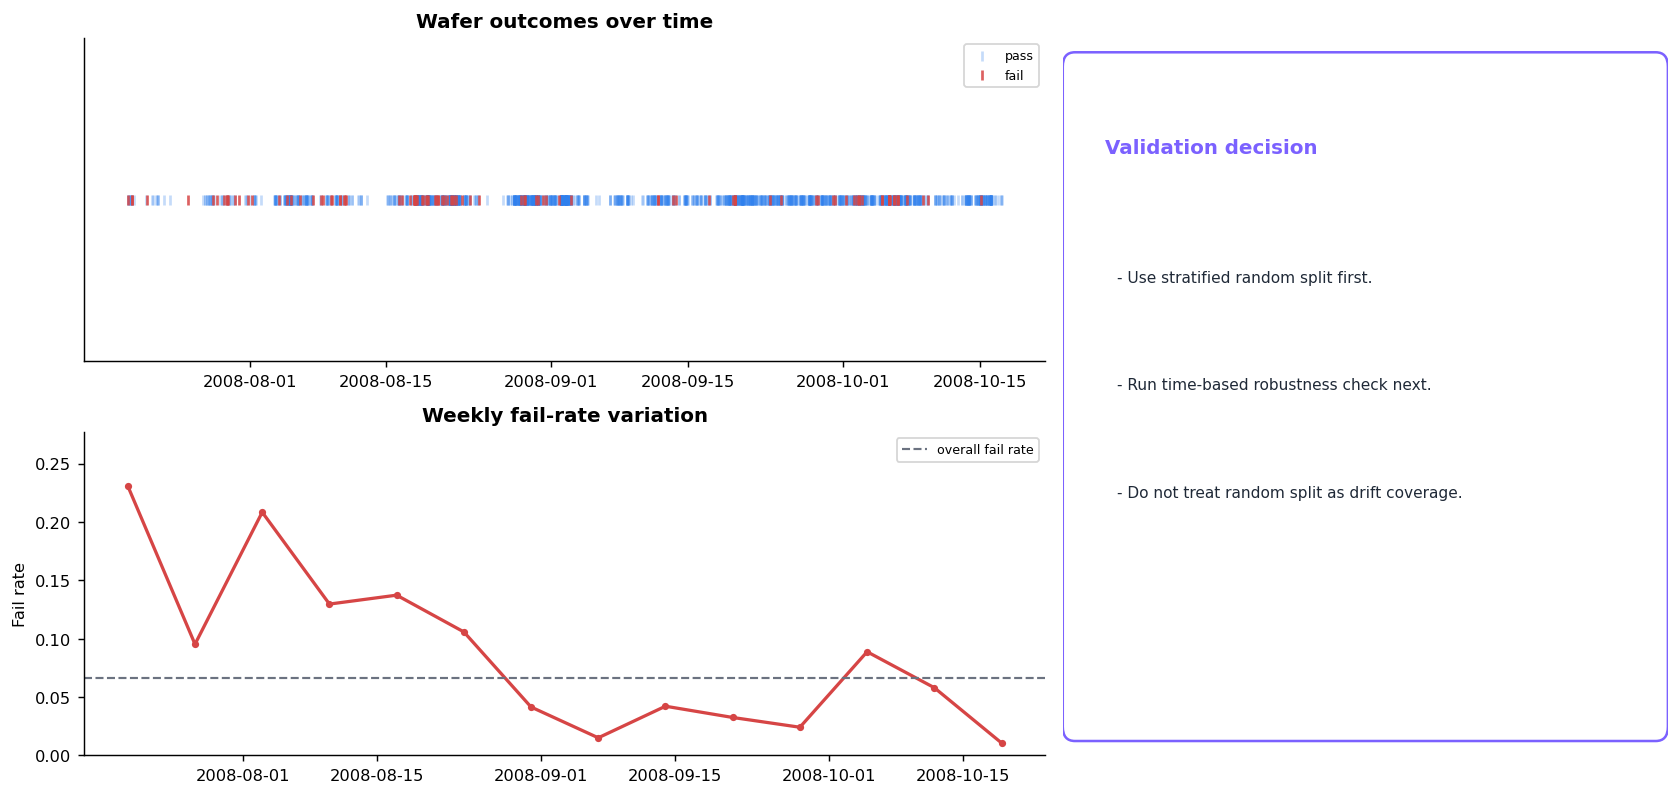

In [11]:
plot_df = df.assign(timestamp_parsed=timestamp_parsed).dropna(subset=["timestamp_parsed"]).sort_values("timestamp_parsed")
fail_mask = plot_df["label"].eq(1)
weekly = plot_df.set_index("timestamp_parsed")["label"].resample("W").agg(total="count", fails="sum")
weekly["fail_rate"] = weekly["fails"] / weekly["total"]

fig = plt.figure(figsize=(13, 6.2))
grid = fig.add_gridspec(2, 2, width_ratios=[1.35, 0.85], height_ratios=[1.0, 1.0])
ax_timeline = fig.add_subplot(grid[0, 0])
ax_weekly = fig.add_subplot(grid[1, 0])
ax_decision = fig.add_subplot(grid[:, 1])

ax_timeline.scatter(plot_df.loc[~fail_mask, "timestamp_parsed"], np.zeros((~fail_mask).sum()), marker="|", alpha=0.28, color=BLUE, label="pass")
ax_timeline.scatter(plot_df.loc[fail_mask, "timestamp_parsed"], np.zeros(fail_mask.sum()), marker="|", alpha=0.85, color=RED, label="fail")
ax_timeline.set_title("Wafer outcomes over time")
ax_timeline.set_yticks([])
ax_timeline.legend(loc="upper right", fontsize=7)

ax_weekly.plot(weekly.index, weekly["fail_rate"], color=RED, linewidth=1.8, marker="o", markersize=3)
ax_weekly.axhline(df["label"].mean(), color=GRAY, linestyle="--", linewidth=1.2, label="overall fail rate")
ax_weekly.set_title("Weekly fail-rate variation")
ax_weekly.set_ylabel("Fail rate")
ax_weekly.set_ylim(0, max(weekly["fail_rate"].max() * 1.2, df["label"].mean() * 2))
ax_weekly.legend(fontsize=7)

decision_card(
    ax_decision,
    "Validation decision",
    [
        "Use stratified random split first.",
        "Run time-based robustness check next.",
        "Do not treat random split as drift coverage.",
    ],
    PURPLE,
)
plt.tight_layout()

## 8. Decision Register

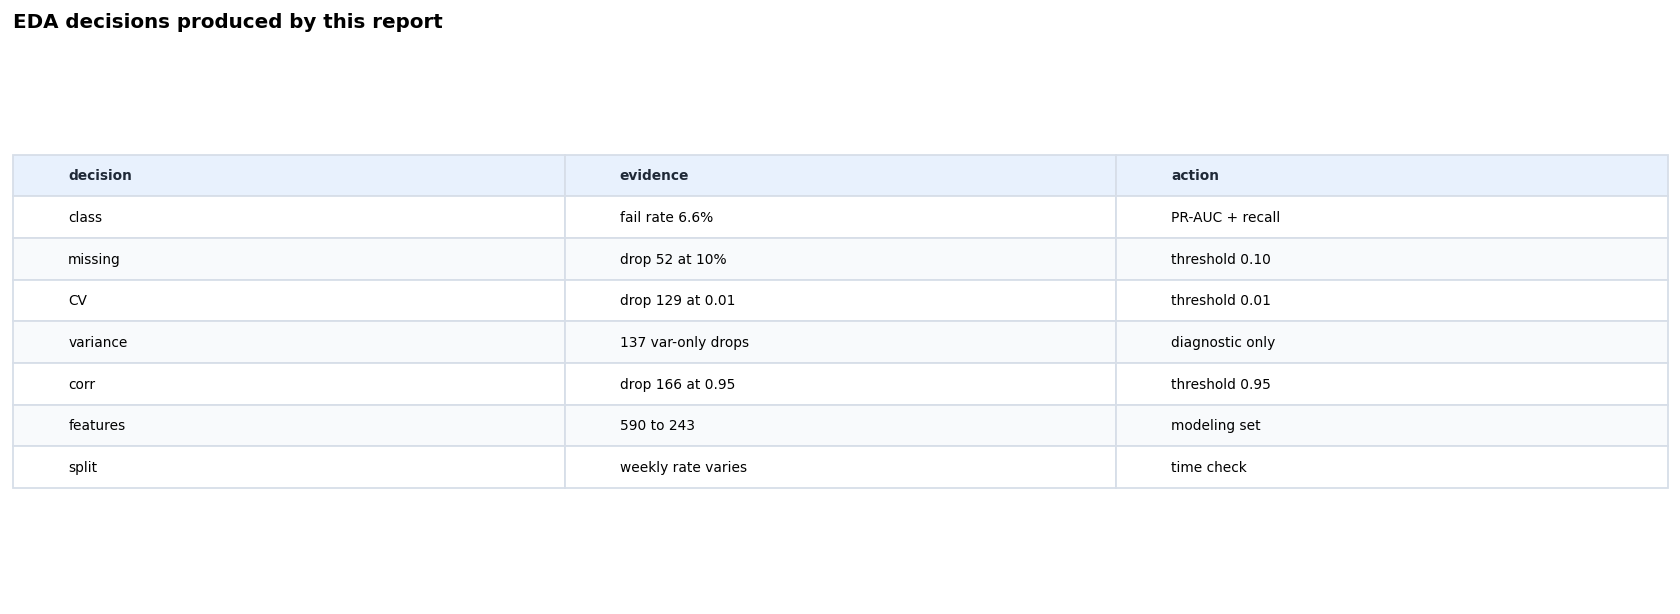

In [12]:
decision_register = pd.DataFrame(
    [
        {"decision": "class", "evidence": f"fail rate {df['label'].mean():.1%}", "action": "PR-AUC + recall"},
        {"decision": "missing", "evidence": f"drop {len(missing_drop)} at 10%", "action": "threshold 0.10"},
        {"decision": "CV", "evidence": f"drop {len(cv_drop)} at 0.01", "action": "threshold 0.01"},
        {"decision": "variance", "evidence": f"{len(abs_only_drop)} var-only drops", "action": "diagnostic only"},
        {"decision": "corr", "evidence": f"drop {len(corr_drop)} at 0.95", "action": "threshold 0.95"},
        {"decision": "features", "evidence": f"590 to {len(corr_keep)}", "action": "modeling set"},
        {"decision": "split", "evidence": "weekly rate varies", "action": "time check"},
    ]
)

fig, ax = plt.subplots(figsize=(13, 4.8))
report_table(ax, decision_register, "EDA decisions produced by this report", max_rows=len(decision_register), font_size=7.6, scale_y=1.65)
plt.tight_layout()